In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


In [2]:
from scipy.optimize import curve_fit
from uncertainties import ufloat
import math

def func(x, a, b):
    return a*x + b

def fit_logPulse(x, y, start, stop):
    popt, pcov = curve_fit(func, x[start:stop], y[start:stop])
    return popt[0], np.sqrt(np.diag(pcov))[0], popt[1], np.sqrt(np.diag(pcov))[1]

def str_with_err(value, error):
    digits = -int(math.floor(math.log10(error)))
    return "{0:.{2}f}({1:.0f})".format(value, error*10**digits, digits)

In [3]:
# Z1 low bg 50V
series_list=['23240109_075338', '23240109_021236', 
'23240108_203134', '23231221_101235', 
'23231221_015705', '23231220_190923', 
'23231220_122140', '23231220_053358', 
'23231220_012745', '23231219_184002', 
'23231219_110331', '23231219_034952', 
'23231218_223530', '23231218_190035', 
'23231218_152721', '23231218_093255', 
'23231218_024511', '23231217_212512', 
'23231217_171613', 
'23231217_135018', '23231216_233807', 
'23231216_211119', '23231216_194929', 
'23231216_182937', '23231216_173436', 
'23231216_145300', '23231216_100125', 
'23231216_043946', '23231216_013604'] # Ge calibration  

In [4]:
ProdTag = 'CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6'

In [5]:
filepath = [f'/scratch/group/mitchcomp/CDMS/data/CDMS/CUTE/R37/Processed/Releases/{ProdTag}/Submerged/{ProdTag}_{i}.root' for i in series_list]

In [6]:
det = 1 # detector number

df = CDataFrame("rqDir/zip"+str(det), filepath, friends = [[x+":rqDir/eventTree" for x in filepath]])

In [7]:
## Apply some basic data quality filters and get the RQs you're interested in
logfile = '"cute_tower3testing.log"'
df = df.Define("LEDLogFile", logfile) 
df = df.CDefine("LEDOn", supercuts.ledOn_old, ["EventTime", "LEDLogFile"])
df = df.Filter("!LEDOn")
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(det), "PTOFamps>0"])

In [8]:
channels = [f"P{letter}S{side}" for side in [1, 2] for letter in ["A", "B", "C", "D", "E", "F"]]
RQs = (["SeriesNumber", "PTOFamps", "PTINTall", "EventNumber", "EventTime"] + [chan + "peaknum" for chan in channels])
df_rqs = df_filtered.AsNumpy(RQs)

In [9]:
peaknum = np.mean([df_rqs[chan + "peaknum"] for chan in channels], axis = 0)
cPileup = ((peaknum < 1.5) & (df_rqs['PTOFamps'] < 1e-5)) | ((peaknum < 1.5) & (peaknum > 0.5) & (df_rqs['PTOFamps'] > 1e-5))

In [10]:
def linearize(x):
    return 1/b * (np.exp(x / a) - 1)

def pt2keV(x):
    lin_pt = linearize(x)
    recoilE = lin_pt * calibFac / LukeFac
    return recoilE

In [11]:
a, b = 2.08e-04, 1.63e+01
calibFac = 21000
LukeFac = 1 + 50 / 3
df_rqs['PTOFamps_keVee'] = pt2keV(df_rqs['PTOFamps'])

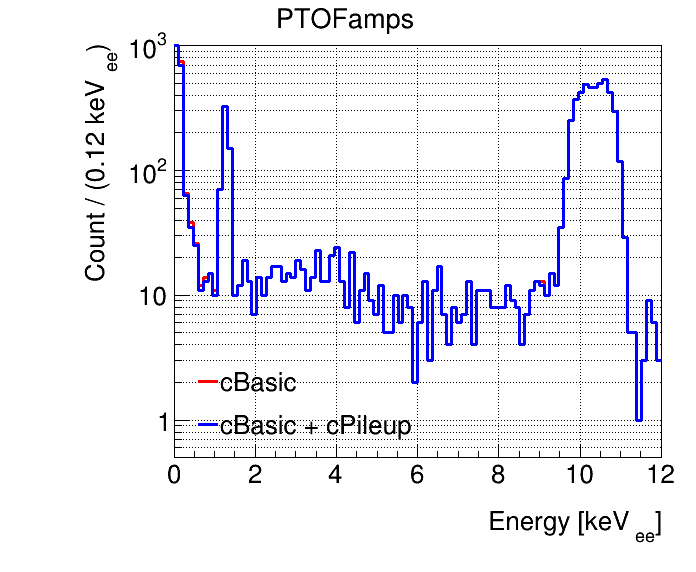

In [12]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 12
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 3)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("h1", "PTOFamps;Energy [keV_{ee}]" + ";Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data1 = df_rqs['PTOFamps_keVee']

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kRed)
h1.SetMaximum(1000)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h2 = ROOT.TH1F("h2", ";Energy [keV_{ee}]" + ";Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data2 = df_rqs['PTOFamps_keVee'][cPileup]

for value in data2:
    h2.Fill(value)
h2.SetLineWidth(3)
h2.SetLineColor(ROOT.kBlue)
    
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetXaxis().SetTitleOffset(1.5)
h1.GetYaxis().SetTitleSize(0.05)

# Optionally, add a legend to differentiate the histograms
legend = ROOT.TLegend(0.28, 0.22, 0.43, 0.37)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(h1, "cBasic", "l")
legend.AddEntry(h2, "cBasic + cPileup", "l")
legend.SetTextSize(0.05)

c.SetLeftMargin(0.25)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
h1.Draw()
h2.Draw("SAME")
legend.Draw()
c.SetLogy()
c.SetGrid(1,1)
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


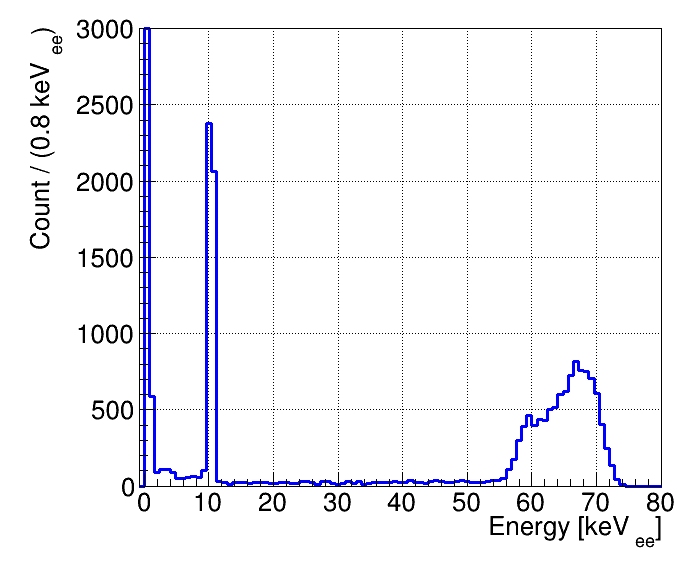

In [13]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 80
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", ";Energy [keV_{ee}];Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps_keVee']

for value in data:
    h.Fill(value)
h.SetLineWidth(3)
h.SetLineColor(ROOT.kBlue)
    
h.SetMinimum(0)
h.SetMaximum(3000)
h.GetXaxis().SetLabelSize(0.05)
h.GetYaxis().SetLabelSize(0.05)
h.GetXaxis().SetTitleSize(0.05)
h.GetYaxis().SetTitleSize(0.05)
h.GetXaxis().SetRangeUser(-30, 80)

c = ROOT.TCanvas("c", "Canvas", 700, 600)
c.SetLeftMargin(0.2)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.05)
h.Draw()
c.SetGrid(1,1)
c.Draw()

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


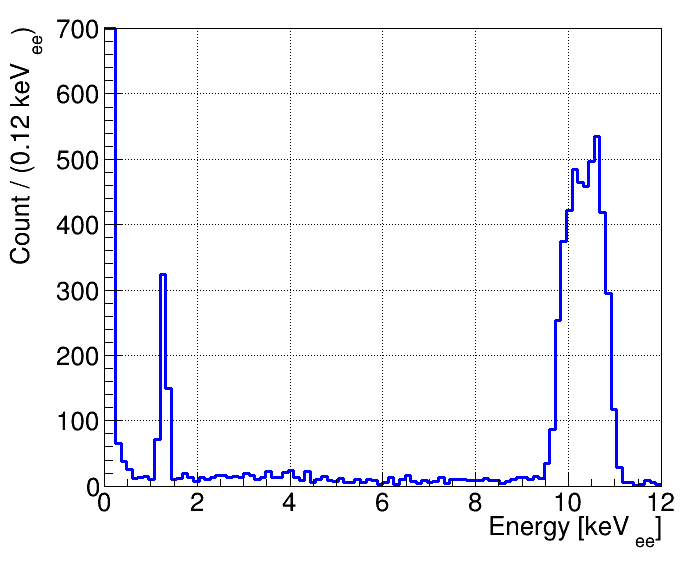

In [14]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 12
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", ";Energy [keV_{ee}];Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps_keVee']

# Fill the histogram with data from the NumPy array
for value in data:
    h.Fill(value)
h.SetLineWidth(3)  # Thicker line
h.SetLineColor(ROOT.kBlue)
    
h.SetMinimum(0)
h.SetMaximum(700)  # Adjust based on your data
h.GetXaxis().SetLabelSize(0.05)
h.GetYaxis().SetLabelSize(0.05)
h.GetXaxis().SetTitleSize(0.05)
h.GetYaxis().SetTitleSize(0.05)
#h.GetXaxis().SetRangeUser(-2, 35)

# Draw the histogram
c = ROOT.TCanvas("c", "Canvas", 700, 600)
c.SetLeftMargin(0.15)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.05)
h.Draw()
c.SetGrid(1,1)
c.Draw()

In [15]:
L_peak_data = df_rqs['PTOFamps_keVee'][(df_rqs['PTOFamps_keVee'] >= 0.85) & (df_rqs['PTOFamps_keVee'] <= 1.7)]
K_peak_data = df_rqs['PTOFamps_keVee'][(df_rqs['PTOFamps_keVee'] >= pt2keV(20e-6)) & (df_rqs['PTOFamps_keVee'] <= pt2keV(34e-6))]

 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 #mu1         1.28000e+00  2.00000e-02    1.20000e+00  1.40000e+00
     2 #sigma1      1.75000e-01  1.25000e-02    1.00000e-02  2.00000e-01
     3 frac         8.70000e-01  6.50000e-02    0.00000e+00  1.00000e+00
 **********
 **    3 **SET ERR         0.5
 **********
 **********
 **    4 **SET PRINT           1
 **********
 **********
 **    5 **SET STR           1
 **********
 NOW USING STRATEGY  1: TRY TO BALANCE SPEED AGAINST RELIABILITY
 **********
 **    6 **MIGRAD        1500           1
 **********
 FIRST CALL TO USER FUNCTION AT NEW START POINT, WITH IFLAG=4.
 START MIGRAD MINIMIZATION.  STRATEGY  1.  CONVERGENCE WHEN EDM .LT. 1.00e-03
 FCN=-551.983 FROM MIGRAD    STATUS=INITIATE       29 CALLS          30 TOTAL
                     EDM= unknown      STRATEGY= 1      NO ERROR MATRIX       
  

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


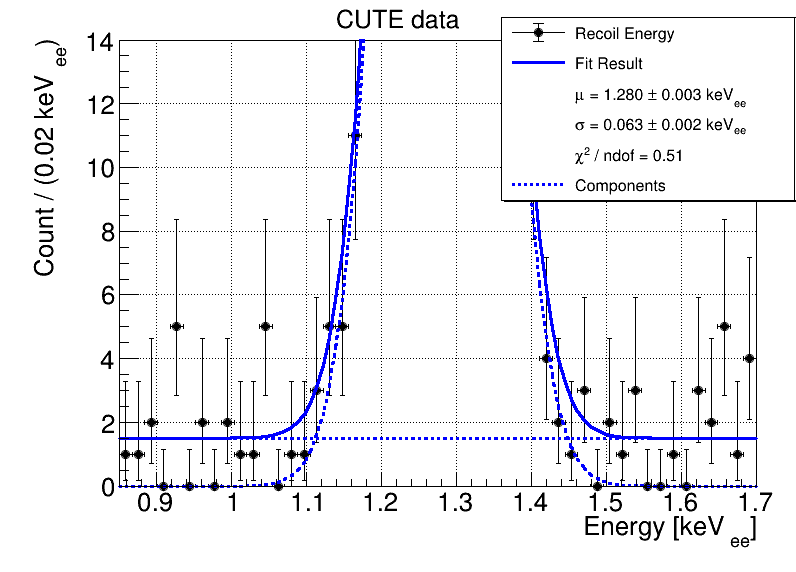

In [16]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0.85
bins_end = 1.7
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", ";Energy [keV_{ee}];Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps_keVee']

# Fill the histogram with data from the NumPy array
for value in data:
    h.Fill(value)

x = ROOT.RooRealVar("x", "x", bins_start, bins_end)  # use your histogram's x range

mean = ROOT.RooRealVar("#mu1", "#mu", 1.28, 1.2, 1.4)
sigma = ROOT.RooRealVar("#sigma1", "#sigma", 0.175, 0.01, 0.2)
gauss = ROOT.RooGaussian("gauss", "Gaussian PDF", x, mean, sigma)

flat = ROOT.RooUniform("flat", "Uniform PDF", x)

frac = ROOT.RooRealVar("frac", "signal fraction", 0.87, 0.0, 1.0)

model = ROOT.RooAddPdf("model", "gauss + flat", ROOT.RooArgList(gauss, flat), ROOT.RooArgList(frac))
data = ROOT.RooDataHist("data", "binned data", ROOT.RooArgList(x), h)

#fit_result = model.fitTo(data)  # binned by default for RooDataHist
nll = model.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.migrad()

fit_result = m.save()

frame = x.frame(ROOT.RooFit.Title("CUTE data"))
frame.SetLabelSize(0.05)
# Change axis labels
frame.GetXaxis().SetTitle("Energy [keV_{ee}]")
frame.GetYaxis().SetTitle(f"Count / (" + str(bindiff) + " keV_{ee})")
frame.GetXaxis().SetLabelSize(0.05)
frame.GetYaxis().SetLabelSize(0.05)
frame.GetXaxis().SetTitleSize(0.05)
frame.GetYaxis().SetTitleSize(0.05)

data.plotOn(frame, ROOT.RooFit.Name("Recoil Energy"))
model.plotOn(frame, ROOT.RooFit.Name("Fit Result"))
model.plotOn(frame, ROOT.RooFit.Components("gauss"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue), ROOT.RooFit.Name("Components"))
model.plotOn(frame, ROOT.RooFit.Components("flat"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))

upper_bound = ROOT.RooFormulaVar("upperBound", "@0 + 3 * @1", ROOT.RooArgList(mean, sigma))
lower_bound = ROOT.RooFormulaVar("lowerBound", "@0 - 3 * @1", ROOT.RooArgList(mean, sigma))
mean_upper_bound = upper_bound.getVal()
mean_lower_bound = lower_bound.getVal()
x.setRange("gaussRange", mean_lower_bound, mean_upper_bound)

frame_narrow = x.frame(ROOT.RooFit.Range("gaussRange"), ROOT.RooFit.Title("Narrow"))

# Plot data and model within the narrow range
data.plotOn(frame_narrow, ROOT.RooFit.Range("gaussRange"), ROOT.RooFit.Name("data_narrow"))
model.plotOn(frame_narrow,
             ROOT.RooFit.Range("gaussRange"),
             ROOT.RooFit.Name("model_narrow"))
nbins = np.round(mean_upper_bound - mean_lower_bound) / bindiff
chi2_narrow = frame_narrow.chiSquare(3)

# Create legend
legend = ROOT.TLegend(0.63, 0.65, 1, 0.97)
legend.SetBorderSize(2)
legend.SetFillColor(0)

# Add entries by retrieving plotted objects by name
legend.AddEntry(frame.findObject("Recoil Energy"),  "Recoil Energy", "lep")
legend.AddEntry(frame.findObject(f"Fit Result"), f"Fit Result", "l")
legend.AddEntry(0, "#mu = " + f"{mean.getVal():.3f} #pm {mean.getPropagatedError(fit_result):.3f}" + " keV_{ee}", "")
legend.AddEntry(0, "#sigma = " + f"{sigma.getVal():.3f} #pm {sigma.getPropagatedError(fit_result):.3f}" + " keV_{ee}", "")
legend.AddEntry(0, "#chi^{2} / ndof = " + f"{chi2_narrow:.2f}", "")
legend.AddEntry(frame.findObject("Components"), "Components", "l")
legend.SetTextSize(0.03)

frame.SetMinimum(0)
#frame.SetMaximum(72)  # Adjust based on your data
frame.SetMaximum(14)  # Adjust based on your data
    
c = ROOT.TCanvas("c", "Fit Canvas", 800, 600)
c.SetLeftMargin(0.15)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.07)
c.SetGrid(1,1)
frame.Draw()
legend.Draw()
c.Draw()

In [22]:
upper_bound = ROOT.RooFormulaVar("upperBound", "@0 + 3 * @1", ROOT.RooArgList(mean, sigma))
lower_bound = ROOT.RooFormulaVar("lowerBound", "@0 - 3 * @1", ROOT.RooArgList(mean, sigma))

mean_upper_bound = upper_bound.getVal()
err_upper_bound = upper_bound.getPropagatedError(fit_result)
mean_lower_bound = lower_bound.getVal()
err_lower_bound = lower_bound.getPropagatedError(fit_result)

print('The range of the peak is ' + str_with_err(mean_lower_bound, err_lower_bound) + ' keV to ' + str_with_err(mean_upper_bound, err_upper_bound) + ' keV')

uniform_norm = ROOT.RooFormulaVar("norm", "1 - @0", ROOT.RooArgList(frac))
nevent = ROOT.RooRealVar("#nevent", "#number of fitted events", len(L_peak_data)) # make sure this is up to date!
binwidth = ROOT.RooRealVar("#binwidth", "#binwidth", (bins_end - bins_start) / nbins)
uniform_height = ROOT.RooRealVar("#height", "#height", 1 / (bins_end - bins_start))

uniform_count = ROOT.RooProduct("#count", "(1 - frac1) * nevent * binwidth * 1 / (range)", ROOT.RooArgList(uniform_norm, nevent, binwidth, uniform_height))

uniform_magnitude = uniform_count.getVal() # count / bin
uniform_magnitude_err = uniform_count.getPropagatedError(fit_result) # count / bin
fitted_bins = (mean_upper_bound - mean_lower_bound) / ((bins_end - bins_start) / nbins)
max_bins = (mean_upper_bound + err_upper_bound - mean_lower_bound + err_lower_bound) / ((bins_end - bins_start) / nbins)
min_bins = (mean_upper_bound - err_upper_bound - mean_lower_bound - err_lower_bound) / ((bins_end - bins_start) / nbins)
fitted_bins_err = abs(np.mean([max_bins, min_bins]) - fitted_bins)

integrated_uniform = uniform_magnitude * fitted_bins
integrated_uniform_err = uniform_magnitude_err * fitted_bins #np.sqrt( (uniform_magnitude_err * fitted_bins)**2 + (uniform_magnitude * fitted_bins_err)**2 )

rangeCut = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound)
rangeCut_max = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound - err_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound + err_upper_bound)
rangeCut_min = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound + err_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound - err_upper_bound)

count = sum(rangeCut)
count_stat = np.sqrt(count)
count_variation = np.mean([abs(count - sum(rangeCut_min)), abs(count - sum(rangeCut_max))])
count_err = np.sqrt( count_stat**2 + count_variation**2 )

print('The number of events inside the peak range is ' + str(round(count, 2)) + ' +/- ' + str(round(count_err, 2)))
print('The number of events in the background of the peak range is ' + str(round(integrated_uniform, 2)) + ' +/- ' + str(round(integrated_uniform_err, 2)))

peak_evts = count - integrated_uniform
peak_evts_err = np.sqrt( count_err ** 2 + integrated_uniform_err ** 2 )
print('The number of non-background events in the peak is ' + str(round(peak_evts, 2)) + ' +/- ' + str(round(peak_evts_err, 2)))

The range of the peak is 1.093(8) keV to 1.468(7) keV
The number of events inside the peak range is 549 +/- 23.52
The number of events in the background of the peak range is 33.32 +/- 4.84
The number of non-background events in the peak is 515.68 +/- 24.01


In [40]:
nevent_window = sum((df_rqs['PTOFamps_keVee'] >= bins_start) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound))

# signal events in peak
print('The fraction of signal events in the peak is ' + str(round(peak_evts / nevent_window * 100, 2)) + ' +/- ' + str(round(peak_evts_err / nevent_window * 100, 2)))

# background events in the peak
print('The fraction of background events in the peak is ' + str(round(integrated_uniform / nevent_window * 100, 2)) + ' +/- ' + str(round(integrated_uniform_err / nevent_window * 100, 2)))

# background events below peak
fitted_bins_tail = (mean_lower_bound - bins_start) / ((bins_end - bins_start) / nbins)
integrated_uniform_tail = uniform_magnitude * fitted_bins_tail
integrated_uniform_tail_err = uniform_magnitude_err * fitted_bins_tail
print('The fraction of background events in the tail is ' + str(round(integrated_uniform_tail / nevent_window * 100, 2)) + ' +/- ' + str(round(integrated_uniform_tail_err / nevent_window * 100, 2)))

# signal events below peak
signal_tail = nevent_window - count - integrated_uniform_tail
signal_tail_err = np.sqrt(count_err**2 + integrated_uniform_tail_err**2)
print('The fraction of signal events in the tail is ' + str(round(signal_tail / nevent_window * 100, 2)) + ' +/- ' + str(round(signal_tail_err / nevent_window * 100, 2)))

# non-peak signal to peak signal
ratio = signal_tail / peak_evts
ratio_err = np.sqrt( (signal_tail_err / peak_evts)**2 + (signal_tail / peak_evts**2 * peak_evts_err)**2)
print('The ratio of non-peak signal to peak signal is ' + str(round(ratio, 3)) + ' +/- ' + str(round(ratio_err, 3)))

The fraction of signal events in the peak is 90.47 +/- 4.21
The fraction of background events in the peak is 5.84 +/- 0.85
The fraction of background events in the tail is 3.78 +/- 0.55
The fraction of signal events in the tail is -0.1 +/- 4.16
The ratio of non-peak signal to peak signal is -0.001 +/- 0.046


[#0] ERROR:InputArguments -- RooArgSet::checkForDup: ERROR argument with name frac is already in this set
[#0] ERROR:InputArguments -- RooArgSet::checkForDup: ERROR argument with name frac is already in this set
[#0] WARNING:Eval -- RooAddPdf::updateCoefCache(model WARNING: sum of PDF coefficients not in range [0-1], value=1.8
[#0] WARNING:Eval -- RooAddPdf::updateCoefCache(model WARNING: sum of PDF coefficients not in range [0-1], value=1.8
[#0] ERROR:InputArguments -- RooArgSet::checkForDup: ERROR argument with name frac is already in this set
 **********
 **    7 **SET PRINT           1
 **********
 **********
 **    8 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 #mu1         1.28000e+00  2.00000e-02    1.20000e+00  1.40000e+00
     2 #sigma1      1.75000e-01  1.25000e-02    1.00000e-02  2.00000e-01
     3 c           -2.00000e+01  1.00000e+01   -1.00000e+02  0.00000e+00
     4 frac         9.00000e-01  5.00000e-02  

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


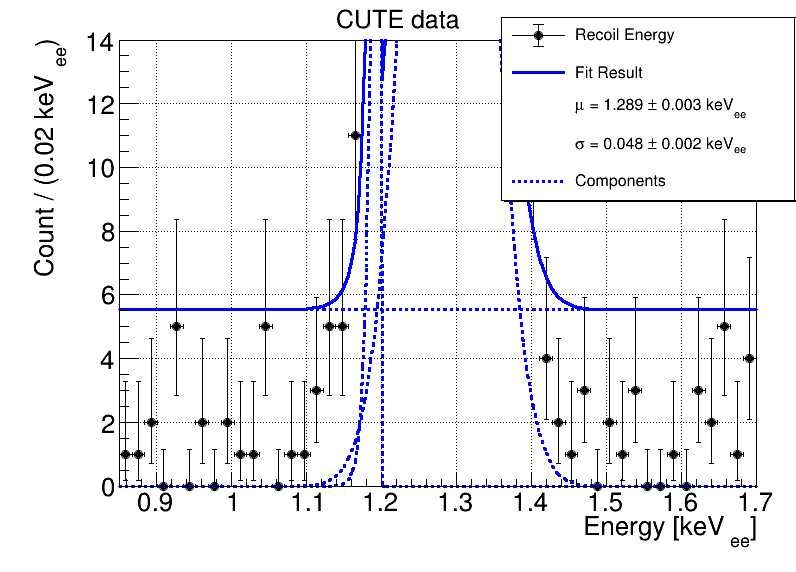

In [18]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0.85
bins_end = 1.7
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", ";Energy [keV_{ee}];Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps_keVee']

# Fill the histogram with data from the NumPy array
for value in data:
    h.Fill(value)

x = ROOT.RooRealVar("x", "x", bins_start, bins_end)  # use your histogram's x range

mean = ROOT.RooRealVar("#mu1", "#mu", 1.28, 1.2, 1.4)
sigma = ROOT.RooRealVar("#sigma1", "#sigma", 0.175, 0.01, 0.2)
gauss = ROOT.RooGaussian("gauss", "Gaussian PDF", x, mean, sigma)

flat = ROOT.RooUniform("flat", "Uniform PDF", x)
# Argus background (left-side tail)
m0   = ROOT.RooRealVar("m0", "Endpoint", 1.1, 1, 1.25)  # same as Gaussian mean
c    = ROOT.RooRealVar("c", "Curvature", -20.0, -100.0, 0.0)
argus = ROOT.RooArgusBG("argus", "Argus Tail", x, m0, c)

frac1 = ROOT.RooRealVar("frac", "signal fraction", 0.9, 0.0, 1.0)
frac2 = ROOT.RooRealVar("frac", "signal fraction", 0.1, 0.0, 1.0)

model = ROOT.RooAddPdf("model", "gauss + flat", ROOT.RooArgList(gauss, flat, argus), ROOT.RooArgList(frac1, frac2))
data = ROOT.RooDataHist("data", "binned data", ROOT.RooArgList(x), h)

#fit_result = model.fitTo(data)  # binned by default for RooDataHist
nll = model.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.migrad()

fit_result = m.save()

frame = x.frame(ROOT.RooFit.Title("CUTE data"))
frame.SetLabelSize(0.05)
# Change axis labels
frame.GetXaxis().SetTitle("Energy [keV_{ee}]")
frame.GetYaxis().SetTitle(f"Count / (" + str(bindiff) + " keV_{ee})")
frame.GetXaxis().SetLabelSize(0.05)
frame.GetYaxis().SetLabelSize(0.05)
frame.GetXaxis().SetTitleSize(0.05)
frame.GetYaxis().SetTitleSize(0.05)

data.plotOn(frame, ROOT.RooFit.Name("Recoil Energy"))
model.plotOn(frame, ROOT.RooFit.Name("Fit Result"))
model.plotOn(frame, ROOT.RooFit.Components("gauss"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue), ROOT.RooFit.Name("Components"))
model.plotOn(frame, ROOT.RooFit.Components("flat"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))
model.plotOn(frame, ROOT.RooFit.Components("argus"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))

#upper_bound = ROOT.RooFormulaVar("upperBound", "@0 + 3 * @1", ROOT.RooArgList(mean, sigma))
#lower_bound = ROOT.RooFormulaVar("lowerBound", "@0 - 3 * @1", ROOT.RooArgList(mean, sigma))
#mean_upper_bound = upper_bound.getVal()
#mean_lower_bound = lower_bound.getVal()
#x.setRange("gaussRange", mean_lower_bound, mean_upper_bound)

#frame_narrow = x.frame(ROOT.RooFit.Range("gaussRange"), ROOT.RooFit.Title("Narrow"))

# Plot data and model within the narrow range
#data.plotOn(frame_narrow, ROOT.RooFit.Range("gaussRange"), ROOT.RooFit.Name("data_narrow"))
#model.plotOn(frame_narrow,
#             ROOT.RooFit.Range("gaussRange"),
#             ROOT.RooFit.Name("model_narrow"))
#nbins = np.round(mean_upper_bound - mean_lower_bound) / bindiff
#chi2_narrow = frame_narrow.chiSquare(3)

# Create legend
legend = ROOT.TLegend(0.63, 0.65, 1, 0.97)
legend.SetBorderSize(2)
legend.SetFillColor(0)

# Add entries by retrieving plotted objects by name
legend.AddEntry(frame.findObject("Recoil Energy"),  "Recoil Energy", "lep")
legend.AddEntry(frame.findObject(f"Fit Result"), f"Fit Result", "l")
legend.AddEntry(0, "#mu = " + f"{mean.getVal():.3f} #pm {mean.getPropagatedError(fit_result):.3f}" + " keV_{ee}", "")
legend.AddEntry(0, "#sigma = " + f"{sigma.getVal():.3f} #pm {sigma.getPropagatedError(fit_result):.3f}" + " keV_{ee}", "")
#legend.AddEntry(0, "#chi^{2} / ndof = " + f"{chi2_narrow:.2f}", "")
legend.AddEntry(frame.findObject("Components"), "Components", "l")
legend.SetTextSize(0.03)

frame.SetMinimum(0)
#frame.SetMaximum(72)  # Adjust based on your data
frame.SetMaximum(14)  # Adjust based on your data
    
c = ROOT.TCanvas("c", "Fit Canvas", 800, 600)
c.SetLeftMargin(0.15)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.07)
c.SetGrid(1,1)
frame.Draw()
legend.Draw()
c.Draw()

 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 #mu1         1.00363e+01  1.19473e-01    9.31354e+00  1.05083e+01
     2 #mu2         1.05083e+01  1.20627e-01    1.01081e+01  1.13144e+01
     3 #sigma1      1.86056e-01  3.16377e-02    3.50686e-02  3.51446e-01
     4 #sigma2      1.68483e-01  3.16377e-02    3.50686e-02  3.51446e-01
     5 c           -2.00000e+01  1.00000e+01   -1.00000e+02  0.00000e+00
     6 c1           4.30000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     7 c2           3.80000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     8 c3           1.00000e-01  5.00000e-02    0.00000e+00  1.00000e+00
     9 m0           9.63839e+00  4.75825e-02    9.31354e+00  9.78936e+00
 **********
 **    3 **SET ERR         0.5
 **********
 **********
 **    4 **SET PRINT           1
 **********
 **********
 **    5 **SET STR           1
 ****

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


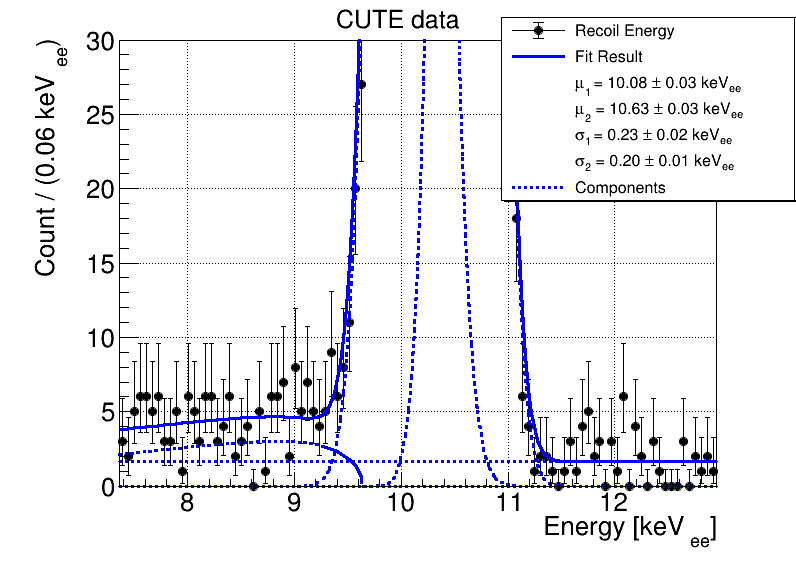

In [41]:
ROOT.gStyle.SetOptStat(0)
bins_start = pt2keV(20e-6)
bins_end = pt2keV(34e-6)
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", ";Energy [keV_{ee}];Count / (" + str(bindiff) + " keV_{ee})", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps_keVee']

# Fill the histogram with data from the NumPy array
for value in data:
    h.Fill(value)

x = ROOT.RooRealVar("x", "x", bins_start, bins_end)  # use your histogram's x range

# Parameters
mean_1 = ROOT.RooRealVar("#mu1", "#mu", pt2keV(26.82e-6), pt2keV(25e-6), pt2keV(28e-6))
sigma_1 = ROOT.RooRealVar("#sigma1", "#sigma", pt2keV(0.53e-6), pt2keV(0.1e-6), pt2keV(1e-6))
mean_2 = ROOT.RooRealVar("#mu2", "#mu", pt2keV(28e-6), pt2keV(27e-6), pt2keV(30e-6))
sigma_2 = ROOT.RooRealVar("#sigma2", "#sigma", pt2keV(0.48e-6), pt2keV(0.1e-6), pt2keV(1e-6))

# Distributions
g1 = ROOT.RooGaussian("g1", "#g1", x, mean_1, sigma_1)
g2 = ROOT.RooGaussian("g2", "#g2", x, mean_2, sigma_2)

flat = ROOT.RooUniform("flat", "#flat", x)

# Argus background (left-side tail)
m0   = ROOT.RooRealVar("m0", "Endpoint", pt2keV(25.82e-6), pt2keV(25e-6), pt2keV(26.2e-6))  # same as Gaussian mean
c    = ROOT.RooRealVar("c", "Curvature", -20.0, -100.0, 0.0)
argus = ROOT.RooArgusBG("argus", "Argus Tail", x, m0, c)

# Weight of distributions
frac1 = ROOT.RooRealVar("c1", "#c", 0.43, 0.0, 1.0)
frac2 = ROOT.RooRealVar("c2", "#c", 0.38, 0.0, 1.0)
frac3 = ROOT.RooRealVar("c3", "#c", 0.1, 0.0, 1.0)
#frac4 = ROOT.RooRealVar("c4", "#c", 0.15, 0.0, 1.0)

# Convert numpy array into RooFit object
model = ROOT.RooAddPdf("model", "model", ROOT.RooArgList(g1, g2, argus, flat), ROOT.RooArgList(frac1, frac2, frac3))
data = ROOT.RooDataHist("data", "binned data", ROOT.RooArgList(x), h)

#fit_result = model.fitTo(data)  # binned by default for RooDataHist
nll = model.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.migrad()

fit_result = m.save()

frame = x.frame(ROOT.RooFit.Title("CUTE data"))
frame.SetLabelSize(0.05)
# Change axis labels
frame.GetXaxis().SetTitle("Energy [keV_{ee}]")
frame.GetYaxis().SetTitle(f"Count / (" + str(bindiff) + " keV_{ee})")
frame.GetXaxis().SetLabelSize(0.05)
frame.GetYaxis().SetLabelSize(0.05)
frame.GetXaxis().SetTitleSize(0.05)
frame.GetYaxis().SetTitleSize(0.05)

data.plotOn(frame, ROOT.RooFit.Name("Recoil Energy"))
model.plotOn(frame, ROOT.RooFit.Name(f"Fit Result"))
model.plotOn(frame, ROOT.RooFit.Components("g1"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue), ROOT.RooFit.Name("Components"))
model.plotOn(frame, ROOT.RooFit.Components("g2"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))
model.plotOn(frame, ROOT.RooFit.Components("argus"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))
model.plotOn(frame, ROOT.RooFit.Components("flat"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))

#upper_bound = ROOT.RooFormulaVar("upperBound", "@0 + 3 * @1", ROOT.RooArgList(mean_2, sigma_2))
#lower_bound = ROOT.RooFormulaVar("lowerBound", "@0 - 3 * @1", ROOT.RooArgList(mean_1, sigma_1))
#mean_upper_bound = upper_bound.getVal()
#mean_lower_bound = lower_bound.getVal()
#x.setRange("gaussRange", bins_start, mean_upper_bound)

#frame_narrow = x.frame(ROOT.RooFit.Range("gaussRange"), ROOT.RooFit.Title("Narrow"))

# Plot data and model within the narrow range
#data.plotOn(frame_narrow, ROOT.RooFit.Range("gaussRange"), ROOT.RooFit.Name("data_narrow"))
#model.plotOn(frame_narrow,
#             ROOT.RooFit.Range("gaussRange"),
#             ROOT.RooFit.Name("model_narrow"))
#chi2_narrow = frame_narrow.chiSquare(9)

# Create legend
legend = ROOT.TLegend(0.63, 0.65, 1, 0.97)
legend.SetBorderSize(2)
legend.SetFillColor(0)

# Add entries by retrieving plotted objects by name
legend.AddEntry(frame.findObject("Recoil Energy"),  "Recoil Energy", "lep")
legend.AddEntry(frame.findObject(f"Fit Result"), f"Fit Result", "l")
legend.AddEntry(0, "#mu_{1} = " + f"{mean_1.getVal():.2f} #pm {mean_1.getPropagatedError(fit_result):.2f}" + " keV_{ee}", "")
legend.AddEntry(0, "#mu_{2} = " + f"{mean_2.getVal():.2f} #pm {mean_2.getPropagatedError(fit_result):.2f}" + " keV_{ee}", "")
legend.AddEntry(0, "#sigma_{1} = " + f"{sigma_1.getVal():.2f} #pm {sigma_1.getPropagatedError(fit_result):.2f}" + " keV_{ee}", "")
legend.AddEntry(0, "#sigma_{2} = " + f"{sigma_2.getVal():.2f} #pm {sigma_2.getPropagatedError(fit_result):.2f}" + " keV_{ee}", "")
#legend.AddEntry(0, "#chi^{2} / ndof = " + f"{chi2_narrow:.2f}", "")
legend.AddEntry(frame.findObject("Components"), "Components", "l")
legend.SetTextSize(0.03)

frame.SetMinimum(0)
#frame.SetMaximum(325)  # Adjust based on your data
frame.SetMaximum(30)  # Adjust based on your data
    
c = ROOT.TCanvas("c", "Fit Canvas", 800, 600)
c.SetLeftMargin(0.15)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.1)
c.SetTopMargin(0.07)
c.SetGrid(1, 1)  # (horizontal, vertical)
frame.Draw()
legend.Draw()
c.Draw()

In [42]:
upper_bound = ROOT.RooFormulaVar("upperBound", "@0 + 3 * @1", ROOT.RooArgList(mean_2, sigma_2))
lower_bound = ROOT.RooFormulaVar("lowerBound", "@0 - 3 * @1", ROOT.RooArgList(mean_1, sigma_1))

mean_upper_bound = upper_bound.getVal()
err_upper_bound = upper_bound.getPropagatedError(fit_result)
mean_lower_bound = lower_bound.getVal()
err_lower_bound = lower_bound.getPropagatedError(fit_result)

print('The range of the peak is ' + str_with_err(mean_lower_bound, err_lower_bound) + ' keV to ' + str_with_err(mean_upper_bound, err_upper_bound) + ' keV')

uniform_norm = ROOT.RooFormulaVar("norm", "1 - @0 - @1 - @2", ROOT.RooArgList(frac1, frac2, frac3))
nevent = ROOT.RooRealVar("#nevent", "#number of fitted events", len(K_peak_data)) # make sure this is up to date!
binwidth = ROOT.RooRealVar("#binwidth", "#binwidth", (bins_end - bins_start) / nbins)
uniform_height = ROOT.RooRealVar("#height", "#height", 1 / (bins_end - bins_start))

uniform_count = ROOT.RooProduct("#count", "(1 - frac1) * nevent * binwidth * 1 / (range)", ROOT.RooArgList(uniform_norm, nevent, binwidth, uniform_height))

uniform_magnitude = uniform_count.getVal() # count / bin
uniform_magnitude_err = uniform_count.getPropagatedError(fit_result) # count / bin
fitted_bins = (mean_upper_bound - mean_lower_bound) / ((bins_end - bins_start) / nbins)
max_bins = (mean_upper_bound + err_upper_bound - mean_lower_bound + err_lower_bound) / ((bins_end - bins_start) / nbins)
min_bins = (mean_upper_bound - err_upper_bound - mean_lower_bound - err_lower_bound) / ((bins_end - bins_start) / nbins)
fitted_bins_err = abs(np.mean([max_bins, min_bins]) - fitted_bins)

integrated_uniform = uniform_magnitude * fitted_bins
integrated_uniform_err = uniform_magnitude_err * fitted_bins #np.sqrt( (uniform_magnitude_err * fitted_bins)**2 + (uniform_magnitude * fitted_bins_err)**2 )

rangeCut = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound)
rangeCut_max = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound - err_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound + err_upper_bound)
rangeCut_min = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound + err_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound - err_upper_bound)

count = sum(rangeCut)
count_stat = np.sqrt(count)
count_variation = np.mean([abs(count - sum(rangeCut_min)), abs(count - sum(rangeCut_max))])
count_err = np.sqrt( count_stat**2 + count_variation**2 )

print('The number of events inside the peak range is ' + str(round(count, 2)) + ' +/- ' + str(round(count_err, 2)))
print('The number of events in the background of the peak range is ' + str(round(integrated_uniform, 2)) + ' +/- ' + str(round(integrated_uniform_err, 2)))

peak_evts = count - integrated_uniform
peak_evts_err = np.sqrt( count_err ** 2 + integrated_uniform_err ** 2 )
print('The number of non-background events in the peak is ' + str(round(peak_evts, 2)) + ' +/- ' + str(round(peak_evts_err, 2)))

The range of the peak is 9.38(3) keV to 11.23(2) keV
The number of events inside the peak range is 4487 +/- 67.03
The number of events in the background of the peak range is 54.59 +/- 7.57
The number of non-background events in the peak is 4432.41 +/- 67.46


In [44]:
nevent_window = sum((df_rqs['PTOFamps_keVee'] >= bins_start) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound))

# signal events in peak
print('The fraction of signal events in the peak is ' + str(round(peak_evts / nevent_window * 100, 2)) + ' +/- ' + str(round(peak_evts_err / nevent_window * 100, 3)))

# background events in the peak
print('The fraction of background events in the peak is ' + str(round(integrated_uniform / nevent_window * 100, 2)) + ' +/- ' + str(round(integrated_uniform_err / nevent_window * 100, 2)))

# background events below peak
fitted_bins_tail = (mean_lower_bound - bins_start) / ((bins_end - bins_start) / nbins)
integrated_uniform_tail = uniform_magnitude * fitted_bins_tail
integrated_uniform_tail_err = uniform_magnitude_err * fitted_bins_tail
print('The fraction of background events in the tail is ' + str(round(integrated_uniform_tail / nevent_window * 100, 2)) + ' +/- ' + str(round(integrated_uniform_tail_err / nevent_window * 100, 2)))

# signal events below peak
signal_tail = nevent_window - count - integrated_uniform_tail
signal_tail_err = np.sqrt(count_err**2 + integrated_uniform_tail_err**2)
print('The fraction of signal events in the tail is ' + str(round(signal_tail / nevent_window * 100, 2)) + ' +/- ' + str(round(signal_tail_err / nevent_window * 100, 2)))

# non-peak signal to peak signal
ratio = signal_tail / peak_evts
ratio_err = np.sqrt( (signal_tail_err / peak_evts)**2 + (signal_tail / peak_evts**2 * peak_evts_err)**2)
print('The ratio of non-peak signal to peak signal is ' + str(round(ratio, 3)) + ' +/- ' + str(round(ratio_err, 3)))

The fraction of signal events in the peak is 95.3 +/- 1.45
The fraction of background events in the peak is 1.17 +/- 0.16
The fraction of background events in the tail is 1.28 +/- 0.18
The fraction of signal events in the tail is 2.24 +/- 1.45
The ratio of non-peak signal to peak signal is 0.024 +/- 0.015


In [43]:
L_sourcesim = ufloat(488, 78)
K_sourcesim = ufloat(4100, 649)
L_CUTE = ufloat(516, 24)
K_CUTE = ufloat(4432, 67)

L_eff = ufloat(0.9150, 0.009576)
K_eff = ufloat(0.91084, 0.0030189)

In [46]:
L_sourcesim = ufloat(488, np.sqrt(78**2 - (0.15 * 488)**2))
K_sourcesim = ufloat(4100, np.sqrt(649**2 - (0.15 * 4100)**2))
L_CUTE = ufloat(516, 24)
K_CUTE = ufloat(4432, 67)

L_eff = ufloat(0.9150, 0.009576)
K_eff = ufloat(0.91084, 0.0030189)

In [48]:
L_CUTE / (L_eff * L_sourcesim) * 37

42.75732330018812+/-3.1187730980601036

In [49]:
K_CUTE / (K_eff * K_sourcesim) * 37

43.91122212570332+/-2.3219415645815724